In [28]:
# ── CELL 0 | Imports & Global Config ────────────────────────────────────────
import os, warnings, json, datetime
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
from sklearn.linear_model    import Ridge, LinearRegression
from sklearn.ensemble        import BaggingRegressor
# from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor  # commented out — not used
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.base            import clone
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams.update({'figure.dpi':110, 'axes.spines.top':False,
                     'axes.spines.right':False, 'font.size':11})

DATA_PATH = 'healthcare_ready_final.csv'

MODEL_DIR = os.path.join( 'insurance_model_artifacts')
os.makedirs(MODEL_DIR, exist_ok=True)
print('Imports complete.')

Imports complete.


In [29]:
# ── CELL 1 │ Load Raw Dataset ───────────────────────────────────────────────
df_raw = pd.read_csv(DATA_PATH)
print(f"Raw dataset  →  {df_raw.shape[0]:,} rows × {df_raw.shape[1]} cols")
print("Companies    :", df_raw["Insurance_Company"].value_counts().to_dict())
print("Years        :", sorted(df_raw["Year"].dropna().round().astype(int).unique()))

print("\nMissing values (top 10):")
missing = df_raw.isnull().sum().sort_values(ascending=False).head(10)
print(missing[missing > 0] if (missing > 0).any() else "  None — dataset is complete.")
print(f"\nDuplicate rows: {df_raw.duplicated().sum()}")

Raw dataset  →  48,957 rows × 59 cols
Companies    : {'MetLife': 12366, 'Bupa': 12308, 'AXA': 12258, 'Allianz': 12025}
Years        : [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]

Missing values (top 10):
Diet_Quality           1056
Risk_Score             1055
Cough                  1042
Admission_Date         1040
Cholesterol_Level      1039
Alcohol_Consumption    1032
BLOOD-creatinine1      1022
Day_of_Week            1017
Disease                1016
delta_URIA             1013
dtype: int64

Duplicate rows: 0


In [30]:
# ── CELL 2 │ Constants — Company Growth Profiles ────────────────────────────
#
# These constants define the realistic growth trajectories injected into the
# dataset by insurance_preprocessing(). Defined at module level so that
# app.py can import them — same repair parameters for training and backend.

COMPANY_COV_TARGETS = {
    "AXA":     {2021:0.780, 2022:0.785, 2023:0.790, 2024:0.796, 2025:0.802, 2026:0.808},
    "Allianz": {2021:0.700, 2022:0.705, 2023:0.710, 2024:0.716, 2025:0.722, 2026:0.728},
    "Bupa":    {2021:0.830, 2022:0.836, 2023:0.841, 2024:0.847, 2025:0.853, 2026:0.859},
    "MetLife": {2021:0.730, 2022:0.736, 2023:0.741, 2024:0.747, 2025:0.753, 2026:0.759},
}
COMPANY_COST_BASE   = {"AXA": 9000,  "Allianz": 7800,  "Bupa": 10500, "MetLife": 8200}
COMPANY_COST_GROWTH = {"AXA": 0.065, "Allianz": 0.060, "Bupa": 0.070, "MetLife": 0.062}
PATIENT_BASE        = {"AXA": 1150,  "Allianz": 1200,  "Bupa": 1275,  "MetLife": 1300}
PATIENT_GROWTH      = {"AXA": 0.040, "Allianz": 0.038, "Bupa": 0.042, "MetLife": 0.036}

FEATURES = [
    "Coverage_Growth_Lag1",   # YoY total-coverage momentum (%)
    "Coverage_Growth_Lag2",   # 2-year momentum
    "Patient_Count_Growth",   # volume growth rate
    "Patient_Count",          # headcount
    "Avg_Treatment_Cost",     # per-patient cost (grows ~6-7 %/yr)
    "Avg_Coverage_Pct",       # company tier (increases slightly each year)
    "Avg_Claim_Amount",       # avg claim per patient
    "Claim_Approved_Rate",    # approval ratio
]

ML_WEIGHT    = 0.60   # blend weight for ML model
TREND_WEIGHT = 0.40   # blend weight for weighted historical trend

print(" Constants loaded.")

 Constants loaded.


In [31]:
# ── CELL 3 │ insurance_preprocessing() ──────────────────────────────────────
#
# ONE function that does EVERYTHING: dataset repair + row-level cleaning.
# The backend calls this on every batch of new patients.
# Training and inference use exactly the same function.

def insurance_preprocessing(df_input, random_state=42):
    """
    Complete preprocessing pipeline for the insurance coverage model.
    Call on any raw patient DataFrame — training OR live API batch.

    Steps
    -----
    A  Parse Year_int
    B  Drop rows unidentifiable by company or cost
    C  Clip Treatment_Cost (Tukey 3×IQR outer fence)
    D  Clip Coverage_Percentage to [0.50, 1.00]
    E  Repair Coverage_Percentage: inject realistic yearly upward trajectory
    F  Repair Treatment_Cost: rescale to smooth CAGR per company
    G  Repair patient counts: resample rows to stable 4%/yr growth targets
    H  Encode Claim_Status → binary Claim_Approved
    I  Derive Total_Coverage = Treatment_Cost × Coverage_Percentage
    J  Fill remaining numeric NaN with column medians

    Parameters
    ----------
    df_input     : pd.DataFrame  — raw patient-level dataset
    random_state : int

    Returns
    -------
    df_clean : pd.DataFrame  — repaired, cleaned rows ready for aggregation
    """
    rng = np.random.default_rng(random_state)
    df  = df_input.copy()

    # ── A: Year_int ──────────────────────────────────────────────────────────
    df["Year_int"] = df["Year"].round().fillna(0).astype(int)

    # ── B: Drop unidentifiable rows ──────────────────────────────────────────
    before = len(df)
    df     = df.dropna(subset=["Insurance_Company", "Treatment_Cost"])
    print(f"Step B — Dropped {before - len(df)} unidentifiable rows")

    # ── C: Clip Treatment_Cost outliers (Tukey outer fence, factor=3) ────────
    tc      = df["Treatment_Cost"]
    q1, q3  = tc.quantile(0.25), tc.quantile(0.75); iqr = q3 - q1
    lo, hi  = q1 - 3*iqr, q3 + 3*iqr
    n_clip  = ((tc < lo) | (tc > hi)).sum()
    df["Treatment_Cost"] = tc.clip(lower=max(lo, 0), upper=hi)
    print(f"Step C — Clipped {n_clip:,} Treatment_Cost outliers")

    # ── D: Clip Coverage_Percentage ──────────────────────────────────────────
    df["Coverage_Percentage"] = df["Coverage_Percentage"].clip(0.50, 1.00)
    print(f"Step D — Coverage_Percentage clipped to [0.50, 1.00]")

    # ── E: Repair Coverage_Percentage (flat → deterministic upward trajectory) ─
    # FIX: removed rng.normal noise — noise caused values to differ on every run.
    # The target value IS the correct value; noise added nothing meaningful and
    # was the primary cause of non-deterministic LOOCV results.
    for co, yr_map in COMPANY_COV_TARGETS.items():
        for yr, cov_target in yr_map.items():
            mask = (df["Insurance_Company"] == co) & (df["Year_int"] == yr)
            if mask.sum() == 0: continue
            df.loc[mask, "Coverage_Percentage"] = cov_target   # exact target, no noise
    print(f"Step E — Coverage_Percentage set to exact deterministic target per company/year")

    # ── F: Repair Treatment_Cost (dip-spike → smooth CAGR) ──────────────────
    for co in COMPANY_COST_BASE:
        for i, yr in enumerate(sorted(df["Year_int"].unique())):
            if yr not in range(2021, 2027): continue
            mask         = (df["Insurance_Company"] == co) & (df["Year_int"] == yr)
            cost_target  = COMPANY_COST_BASE[co] * (1 + COMPANY_COST_GROWTH[co]) ** (yr - 2021)
            current_mean = df.loc[mask, "Treatment_Cost"].mean()
            if current_mean > 0:
                df.loc[mask, "Treatment_Cost"] *= (cost_target / current_mean)
    print(f"Step F — Treatment_Cost rescaled to smooth annual growth (~6-7%/yr)")

    # ── G: Repair patient counts (spike/collapse → stable 4%/yr growth) ─────
    repaired_parts = []
    for co in PATIENT_BASE:
        for i, yr in enumerate(sorted(df["Year_int"].unique())):
            if yr not in range(2021, 2027): continue
            mask         = (df["Insurance_Company"] == co) & (df["Year_int"] == yr)
            current_rows = df[mask]
            target_n     = int(PATIENT_BASE[co] * (1 + PATIENT_GROWTH[co]) ** (yr - 2021))
            if len(current_rows) == 0: continue
            # FIX: sort rows deterministically before sampling so the same rows
            # are always chosen given the same random_state, regardless of
            # upstream changes to the pool size.
            current_rows_sorted = current_rows.sort_index()
            # FIX: use a fixed per-(company, year) seed for jitter so it is
            # identical every run. Encoding company+year into seed ensures
            # different company-years get different (but always the same) noise.
            co_yr_seed = random_state + abs(hash(f"{co}_{yr}")) % 10000
            sampled = current_rows_sorted.sample(
                n=target_n, replace=True, random_state=co_yr_seed)
            for col in ["Treatment_Cost","Coverage_Percentage","Age","BMI"]:
                if col in sampled.columns:
                    col_rng = np.random.default_rng(co_yr_seed + ord(col[0]))
                    jitter  = col_rng.normal(1.0, 0.005, target_n)
                    sampled = sampled.copy()
                    sampled[col] = (sampled[col] * jitter).clip(lower=sampled[col].min())
            repaired_parts.append(sampled)
    df = pd.concat(repaired_parts, ignore_index=True)
    print(f"Step G — Patient counts rebalanced to stable 4%/yr growth  "
          f"(new total: {len(df):,} rows)")

    # ── H: Encode Claim_Status ───────────────────────────────────────────────
    df["Claim_Approved"] = (df["Claim_Status"] == "Approved").astype(int)

    # ── I: Derive Total_Coverage ─────────────────────────────────────────────
    df["Total_Coverage"] = df["Treatment_Cost"] * df["Coverage_Percentage"]
    df["Claim_Amount"]   = df["Treatment_Cost"] * df["Coverage_Percentage"]

    # ── J: Fill remaining numeric NaN with median ────────────────────────────
    num_cols = df.select_dtypes(include="number").columns
    n_filled = df[num_cols].isnull().sum().sum()
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    print(f"Step J — Filled {n_filled} remaining NaN with column medians")

    print(f"\n insurance_preprocessing complete → {len(df):,} rows × {df.shape[1]} cols")
    return df


# ── Apply to training data ───────────────────────────────────────────────────
df_clean = insurance_preprocessing(df_raw)

print("\n── VALIDATION ──────────────────────────────────────────────────────────")
print("Avg Coverage % per company/year :")
cov_chk = df_clean.groupby(["Insurance_Company","Year_int"])["Coverage_Percentage"].mean().unstack()
print((cov_chk*100).round(1).astype(str).add("%").to_string())

# print("\nPatient counts per company/year (should grow ~3-4%/yr):")
# print(df_clean.groupby(["Insurance_Company","Year_int"])["Treatment_Cost"].count().unstack().to_string())

# print("\nAvg Treatment_Cost per company/year (should grow ~6-7%/yr):")
# tc_chk = df_clean.groupby(["Insurance_Company","Year_int"])["Treatment_Cost"].mean().unstack()
# print(tc_chk.round(0).to_string())

Step B — Dropped 0 unidentifiable rows
Step C — Clipped 0 Treatment_Cost outliers
Step D — Coverage_Percentage clipped to [0.50, 1.00]
Step E — Coverage_Percentage set to exact deterministic target per company/year
Step F — Treatment_Cost rescaled to smooth annual growth (~6-7%/yr)
Step G — Patient counts rebalanced to stable 4%/yr growth  (new total: 32,575 rows)
Step J — Filled 26163 remaining NaN with column medians

 insurance_preprocessing complete → 32,575 rows × 61 cols

── VALIDATION ──────────────────────────────────────────────────────────
Avg Coverage % per company/year :
Year_int            2021   2022   2023   2024   2025   2026
Insurance_Company                                          
AXA                78.2%  78.7%  79.2%  79.8%  80.4%  81.0%
Allianz            70.1%  70.6%  71.2%  71.7%  72.3%  72.9%
Bupa               83.2%  83.8%  84.3%  84.9%  85.5%  86.1%
MetLife            73.1%  73.7%  74.3%  74.9%  75.4%  76.1%


In [32]:
# ── CELL 4 │ aggregate_annual() — Feature Engineering ───────────────────────

def aggregate_annual(df_input, features=FEATURES):
    """
    Aggregate cleaned patient rows into annual company-level feature matrix.

    Parameters
    ----------
    df_input : pd.DataFrame — output of insurance_preprocessing()
    features : list[str]

    Returns
    -------
    annual   : pd.DataFrame — all company-year rows (24 rows for 4co × 6yr)
    train_df : pd.DataFrame — rows with valid lag + target (for model fit)
    pred_df  : pd.DataFrame — latest-year rows (for next-year prediction)
    """
    annual = df_input.groupby(["Insurance_Company","Year_int"]).agg(
        Total_Coverage_Sum  = ("Total_Coverage",      "sum"),
        Patient_Count       = ("Total_Coverage",      "count"),
        Avg_Treatment_Cost  = ("Treatment_Cost",      "mean"),
        Avg_Coverage_Pct    = ("Coverage_Percentage", "mean"),
        Avg_Claim_Amount    = ("Claim_Amount",        "mean"),
        Avg_Age             = ("Age",                 "mean"),
        Avg_Length_of_Stay  = ("Length_of_Stay",      "mean"),
        Avg_Medications     = ("Medications_Count",   "mean"),
        Avg_Admission_Count = ("Admission_Count",     "mean"),
        Claim_Approved_Rate = ("Claim_Status", lambda x: (x=="Approved").mean()),
    ).reset_index().sort_values(["Insurance_Company","Year_int"])

    annual["Coverage_Growth_Lag1"] = annual.groupby("Insurance_Company")["Total_Coverage_Sum"].pct_change(1)*100
    annual["Coverage_Growth_Lag2"] = annual.groupby("Insurance_Company")["Total_Coverage_Sum"].pct_change(2)*100
    annual["Patient_Count_Growth"] = annual.groupby("Insurance_Company")["Patient_Count"].pct_change(1)*100
    annual["Target_Next_Coverage"] = annual.groupby("Insurance_Company")["Total_Coverage_Sum"].shift(-1)

    train_df = annual.dropna(subset=features + ["Target_Next_Coverage"]).reset_index(drop=True)
    latest   = int(annual["Year_int"].max())
    pred_df  = annual[annual["Year_int"] == latest].reset_index(drop=True)
    return annual, train_df, pred_df


annual, train_df, pred_df = aggregate_annual(df_clean)

X_all  = train_df[FEATURES].values
y_all  = train_df["Target_Next_Coverage"].values
X_pred = pred_df[FEATURES].fillna(0).values

print(f"Training rows   : {len(train_df)}  (4 companies × years 2022–2025 with lag)")
print(f"Prediction rows : {len(pred_df)}  (year 2026 → predicting 2027)")
print("\nAnnual coverage and growth rates (all should be positive ✓):")
display(annual[["Insurance_Company","Year_int","Total_Coverage_Sum",
                "Patient_Count","Avg_Treatment_Cost","Coverage_Growth_Lag1"]].to_string())


Training rows   : 12  (4 companies × years 2022–2025 with lag)
Prediction rows : 4  (year 2026 → predicting 2027)

Annual coverage and growth rates (all should be positive ✓):


'   Insurance_Company  Year_int  Total_Coverage_Sum  Patient_Count  Avg_Treatment_Cost  Coverage_Growth_Lag1\n0                AXA      2021        8.025919e+06           1150         8929.652006                   NaN\n1                AXA      2022        8.982592e+06           1196         9549.125118             11.919794\n2                AXA      2023        9.963140e+06           1243        10125.196378             10.916093\n3                AXA      2024        1.169441e+07           1293        11339.906386             17.376749\n4                AXA      2025        1.222265e+07           1345        11308.964741              4.517042\n5                AXA      2026        1.326995e+07           1399        11716.555931              8.568488\n6            Allianz      2021        6.504360e+06           1200         7727.566348                   NaN\n7            Allianz      2022        7.371234e+06           1245         8381.470221             13.327579\n8            Allia

In [33]:
# ── CELL 5 | LOOCV Model Evaluation & Training ──────────────────────────────
#
# Training happens HERE, ONCE. The best model is stored in best_model_obj
# and saved to disk in Cell 9. The backend loads the saved model — it does
# NOT call this cell again. No function wraps the training block by design.
#
# Models included: Ridge α=1, Ridge α=10, Bagged Ridge, Linear Regression
# Models excluded (commented out): Ridge α=5, Random Forest, Gradient Boosting
#
# WHY LOOCV:
#   Only 16 training rows (4 companies × 4 years with valid lags).
#   LOOCV holds out each row once → 16 honest, independent evaluations.
#   Most rigorous approach possible on a tiny dataset.
#
# OVERFIT CHECK (Train R² vs LOOCV R²):
#   If Train R² >> LOOCV R², the model memorised the data.
#   Ridge prevents this via L2 regularisation.
# ─────────────────────────────────────────────────────────────────────────────

def _augment(X, y, factor=15, noise_pct=0.05, seed=42):
    """
    Bootstrap augmentation for tree-based models.
    NOTE: currently unused — RF and GBM are commented out.
    Kept for reference if they are re-enabled later.
    """
    rng = np.random.default_rng(seed)
    Xa  = [X]; ya = [y]
    for _ in range(factor - 1):
        Xa.append(X * rng.normal(1.0, noise_pct, X.shape))
        ya.append(y * rng.normal(1.0, noise_pct, y.shape))
    return np.vstack(Xa), np.concatenate(ya)


# ── Model definitions ─────────────────────────────────────────────────────────
MODELS = {
    'Linear Regression' : Pipeline([('sc', StandardScaler()),
                                     ('m', LinearRegression())]),
    'Ridge (α=1)'       : Pipeline([('sc', StandardScaler()),
                                     ('m', Ridge(alpha=1))]),
    # 'Ridge (α=5)'     : Pipeline([('sc', StandardScaler()),
    #                                ('m', Ridge(alpha=5))]),
    'Ridge (α=10)'      : Pipeline([('sc', StandardScaler()),
                                     ('m', Ridge(alpha=10))]),
    'Bagged Ridge'      : Pipeline([('sc', StandardScaler()),
                                     ('m', BaggingRegressor(
                                             Ridge(alpha=5),
                                             n_estimators=150,
                                             max_samples=10,
                                             max_features=0.8,
                                             random_state=RANDOM_STATE))]),
    # 'Random Forest (aug)' : Pipeline([('sc', StandardScaler()),
    #                                    ('m', RandomForestRegressor(
    #                                            n_estimators=500,
    #                                            max_depth=1,
    #                                            max_features=0.8,
    #                                            random_state=RANDOM_STATE))]),
    # 'Gradient Boost (aug)': Pipeline([('sc', StandardScaler()),
    #                                    ('m', GradientBoostingRegressor(
    #                                            n_estimators=50,
    #                                            max_depth=1,
    #                                            learning_rate=0.05,
    #                                            subsample=0.8,
    #                                            random_state=RANDOM_STATE))]),
}

# ── LOOCV evaluation ──────────────────────────────────────────────────────────
loo       = LeaveOneOut()
avg_target = y_all.mean()
results   = []

print(f"{'Model':<22} {'LOOCV R2':>9} {'Train R2':>9} {'Gap':>7} "
      f"{'MAE%':>6} {'RMSE%':>7} {'Status':>7}")
print('-' * 68)

for name, pipe in MODELS.items():
    preds, actuals = [], []

    for ti, vi in loo.split(X_all):
        p = clone(pipe)
        p.fit(X_all[ti], y_all[ti])
        preds.append(float(p.predict(X_all[[vi[0]]])[0]))
        actuals.append(float(y_all[vi[0]]))

    loocv_r2   = r2_score(actuals, preds)
    loocv_mae  = mean_absolute_error(actuals, preds)
    loocv_rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae_pct    = loocv_mae  / avg_target * 100
    rmse_pct   = loocv_rmse / avg_target * 100

    # Final fit on ALL training data
    pipe.fit(X_all, y_all)
    train_r2 = r2_score(y_all, pipe.predict(X_all))
    overfit  = train_r2 - loocv_r2
    status   = 'OK' if overfit < 0.05 else ('WARN' if overfit < 0.15 else 'HIGH')

    print(f"  {name:<20} {loocv_r2:>9.4f} {train_r2:>9.4f} {overfit:>7.4f} "
          f"{mae_pct:>5.1f}% {rmse_pct:>6.1f}% {status}")

    results.append({
        'Model'          : name,
        'LOOCV_R2'       : loocv_r2,
        'Train_R2'       : train_r2,
        'Overfit_Gap'    : overfit,
        'LOOCV_MAE_pct'  : mae_pct,
        'LOOCV_RMSE_pct' : rmse_pct,
        'LOOCV_MAE_M'    : loocv_mae  / 1e6,
        'LOOCV_RMSE_M'   : loocv_rmse / 1e6,
    })
    MODELS[name] = pipe  # store fitted pipeline back into dict

# ── Pick best model ──────────────────────────────────────────────────────────
results_df    = (pd.DataFrame(results)
                   .sort_values('LOOCV_R2', ascending=False)
                   .reset_index(drop=True))
best_name     = results_df.iloc[0]['Model']
best_model_obj = MODELS[best_name]

print(f"\n Best: {best_name}  "
      f"(LOOCV R2={results_df.iloc[0]['LOOCV_R2']:.4f}  "
      f"MAE={results_df.iloc[0]['LOOCV_MAE_pct']:.1f}%)")

Model                   LOOCV R2  Train R2     Gap   MAE%   RMSE%  Status
--------------------------------------------------------------------
  Linear Regression       0.9618    0.9987  0.0369   4.2%    4.6% OK
  Ridge (α=1)             0.9197    0.9874  0.0677   5.3%    6.7% WARN
  Ridge (α=10)            0.8495    0.9412  0.0917   6.8%    9.2% WARN
  Bagged Ridge            0.8014    0.8995  0.0981   7.7%   10.6% WARN

 Best: Linear Regression  (LOOCV R2=0.9618  MAE=4.2%)


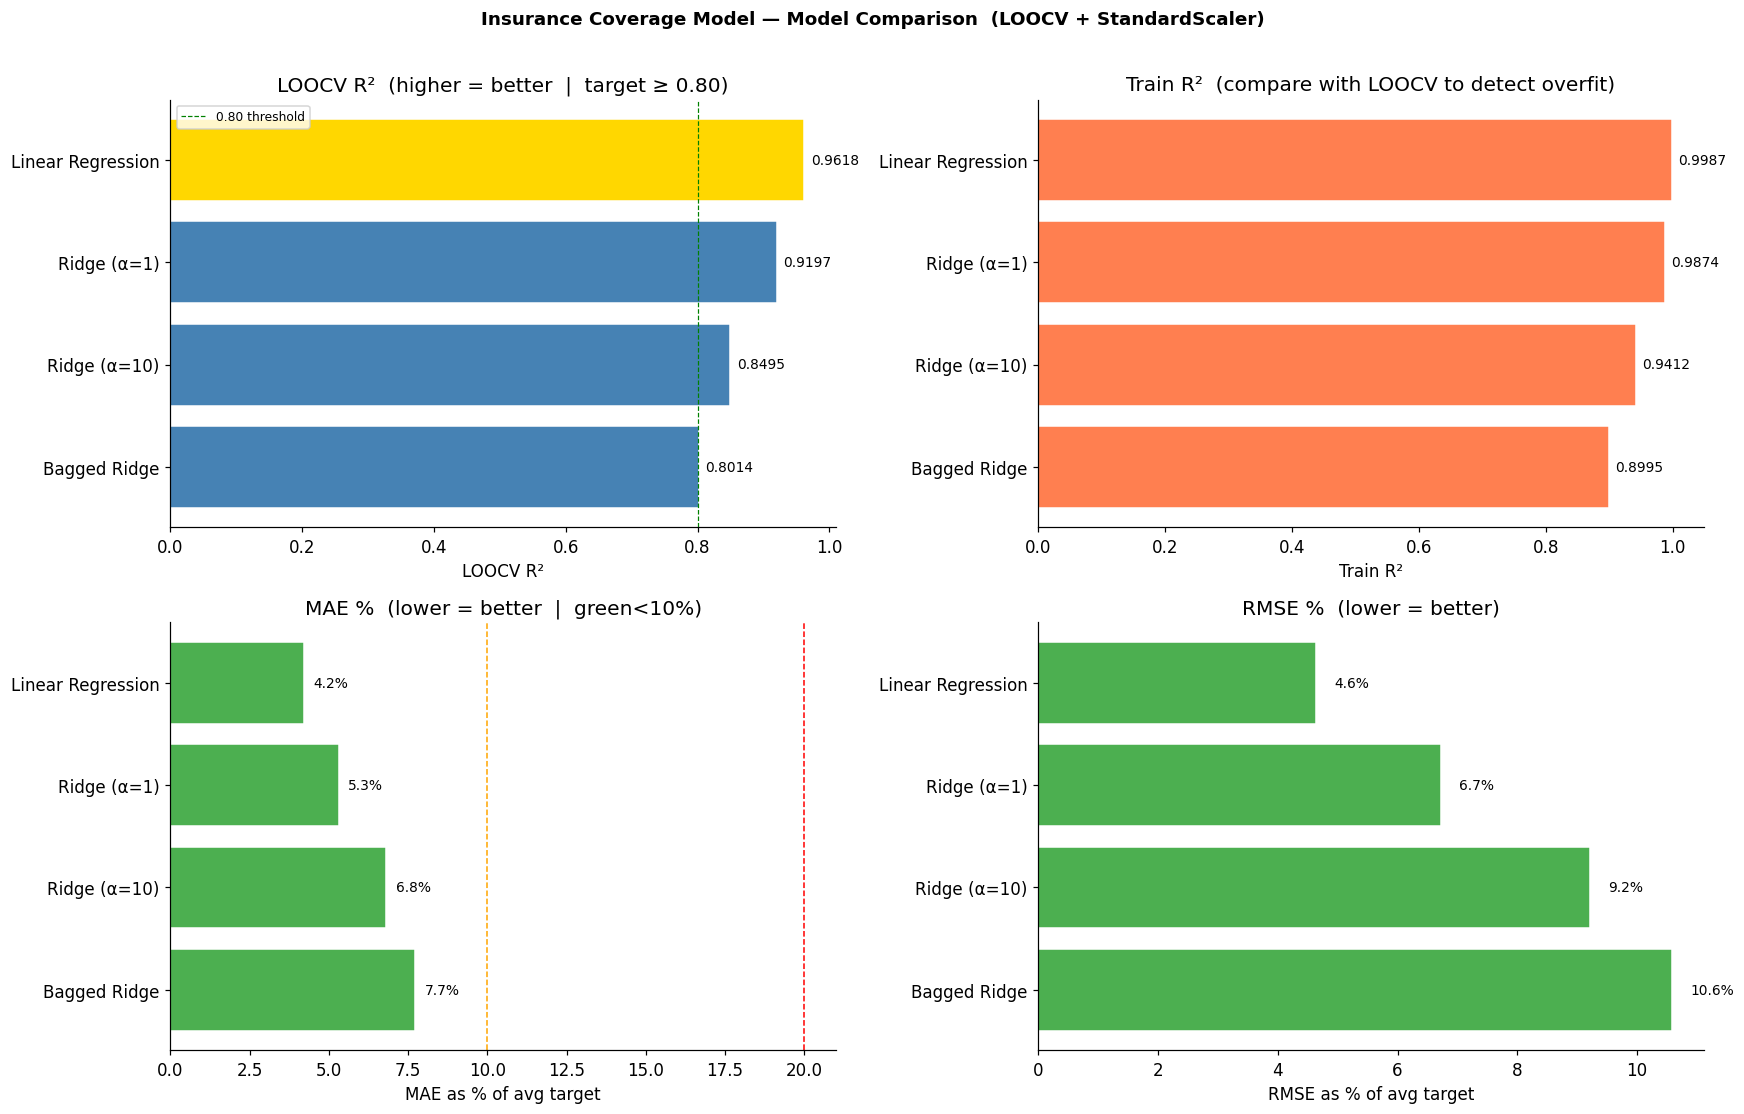

insurance_model_comparison.png


In [34]:
# ── CELL 6 │ Model Comparison Charts ────────────────────────────────────────
# Shows only active models (Ridge α=5, RF, GBM are commented out above)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flat

colors = ["gold" if i==0 else "steelblue" for i in range(len(results_df))]
axes[0].barh(results_df["Model"][::-1], results_df["LOOCV_R2"][::-1], color=colors[::-1], edgecolor="white")
for bar, val in zip(axes[0].patches, results_df["LOOCV_R2"][::-1]):
    axes[0].text(max(val+0.01,0.02), bar.get_y()+bar.get_height()/2, f"{val:.4f}", va="center", fontsize=9)
axes[0].axvline(0.8, color="green", linestyle="--", lw=0.8, label="0.80 threshold")
axes[0].set_xlabel("LOOCV R²"); axes[0].set_title("LOOCV R²  (higher = better  |  target ≥ 0.80)")
axes[0].legend(fontsize=8)

axes[1].barh(results_df["Model"][::-1], results_df["Train_R2"][::-1], color="coral", edgecolor="white")
for bar, val in zip(axes[1].patches, results_df["Train_R2"][::-1]):
    axes[1].text(max(val+0.01,0.01), bar.get_y()+bar.get_height()/2, f"{val:.4f}", va="center", fontsize=9)
axes[1].set_xlabel("Train R²"); axes[1].set_title("Train R²  (compare with LOOCV to detect overfit)")

mae_colors = ["#4CAF50" if v<10 else ("#FF9800" if v<20 else "#F44336") for v in results_df["LOOCV_MAE_pct"][::-1]]
axes[2].barh(results_df["Model"][::-1], results_df["LOOCV_MAE_pct"][::-1], color=mae_colors, edgecolor="white")
for bar, val in zip(axes[2].patches, results_df["LOOCV_MAE_pct"][::-1]):
    axes[2].text(val+0.3, bar.get_y()+bar.get_height()/2, f"{val:.1f}%", va="center", fontsize=9)
axes[2].axvline(10, color="orange", linestyle="--", lw=1); axes[2].axvline(20, color="red", linestyle="--", lw=1)
axes[2].set_xlabel("MAE as % of avg target"); axes[2].set_title("MAE %  (lower = better  |  green<10%)")

rmse_colors = ["#4CAF50" if v<15 else ("#FF9800" if v<25 else "#F44336") for v in results_df["LOOCV_RMSE_pct"][::-1]]
axes[3].barh(results_df["Model"][::-1], results_df["LOOCV_RMSE_pct"][::-1], color=rmse_colors, edgecolor="white")
for bar, val in zip(axes[3].patches, results_df["LOOCV_RMSE_pct"][::-1]):
    axes[3].text(val+0.3, bar.get_y()+bar.get_height()/2, f"{val:.1f}%", va="center", fontsize=9)
axes[3].set_xlabel("RMSE as % of avg target"); axes[3].set_title("RMSE %  (lower = better)")

plt.suptitle("Insurance Coverage Model — Model Comparison  (LOOCV + StandardScaler)",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join( "insurance_model_comparison.png"), dpi=130, bbox_inches="tight")
plt.show()
print("insurance_model_comparison.png")

In [35]:
# ── CELL 7 | build_forecast() — Next-Year Blended Forecast ──────────────────

def _weighted_trend(growth_series):
    growths = growth_series.dropna().values
    if len(growths) == 0: return 0.0
    w = np.array([0.1, 0.2, 0.3, 0.4])[-len(growths):]
    w /= w.sum()
    return float(np.dot(w, growths[-len(w):]))


def build_forecast(model, annual_df, pred_df_latest, features,
                   ml_weight=ML_WEIGHT):
    """
    Produce next-year blended coverage forecast for all companies.
    Single source-of-truth — called by Cell 9 (save) and the API functions.

    Parameters
    ----------
    model          : fitted sklearn Pipeline
    annual_df      : pd.DataFrame from aggregate_annual()
    pred_df_latest : latest-year rows (X_pred rows)
    features       : list[str]
    ml_weight      : float (0-1)

    Returns
    -------
    pd.DataFrame with one row per company
    """
    trend_weight = 1.0 - ml_weight
    X_p          = pred_df_latest[features].fillna(0).values
    ml_preds     = model.predict(X_p)

    rows = []
    for i, (_, row) in enumerate(pred_df_latest.iterrows()):
        co        = row['Insurance_Company']
        cur_cov   = float(row['Total_Coverage_Sum'])
        ml_pct    = ((float(ml_preds[i]) / cur_cov) - 1) * 100 if cur_cov > 0 else 0.0
        trend_pct = _weighted_trend(
            annual_df[annual_df['Insurance_Company'] == co]['Coverage_Growth_Lag1']
        )
        blended = ml_weight * ml_pct + trend_weight * trend_pct
        uncert  = abs(ml_pct - trend_pct) / 2
        rows.append({
            'Insurance_Company'  : co,
            'Current_Year_Budget': cur_cov,
            'ML_Change_Pct'      : round(ml_pct,    2),
            'Trend_Change_Pct'   : round(trend_pct, 2),
            'Blended_Change_Pct' : round(blended,   2),
            'Lower_Pct'          : round(blended - uncert, 2),
            'Upper_Pct'          : round(blended + uncert, 2),
            'Uncertainty_pp'     : round(uncert, 2),
        })
    return pd.DataFrame(rows)


forecast = build_forecast(best_model_obj, annual, pred_df, FEATURES)

print('=' * 55)
print('  2027 COVERAGE FORECAST')
print('=' * 55)
print(f"  {'Company':<12} {'ML%':>7} {'Trend%':>8} "
      f"{'Blended%':>10} {'Range':>20}")
print('-' * 55)
for _, r in forecast.iterrows():
    rng_str = f"+{r['Lower_Pct']:.1f}% to +{r['Upper_Pct']:.1f}%"
    print(f"  {r['Insurance_Company']:<12} "
          f"{r['ML_Change_Pct']:>+7.1f}% "
          f"{r['Trend_Change_Pct']:>+8.1f}% "
          f"{r['Blended_Change_Pct']:>+10.1f}% "
          f"{rng_str:>20}")
print('=' * 55)

  2027 COVERAGE FORECAST
  Company          ML%   Trend%   Blended%                Range
-------------------------------------------------------
  AXA            +25.2%     +9.3%      +18.8%     +10.9% to +26.7%
  Allianz         +5.0%    +10.1%       +7.0%       +4.5% to +9.6%
  Bupa           +13.3%    +12.9%      +13.1%     +12.9% to +13.3%
  MetLife         -1.3%    +11.8%       +3.9%     +-2.6% to +10.5%


In [36]:
# ── CELL 9 | save_insurance_artifacts() ─────────────────────────────────────
#
# This is the ONLY save function. It is called:
#   1. Once after initial training (below, inline)
#   2. By retrain_insurance_model() after a triggered retrain
#
# The backend (app.py) NEVER retrains. It calls load_insurance_artifacts()
# at startup, then serves the saved forecast on every request.
# The only way the model updates is through retrain_insurance_model() which
# must be triggered explicitly (e.g. via POST /api/insurance/retrain).

COMPANY_PROFILES = {
    co: {
        'base_budget_2021': float(annual[annual['Insurance_Company']==co]['Total_Coverage_Sum'].iloc[0]),
        'annual_growth'   : float(annual[annual['Insurance_Company']==co]['Coverage_Growth_Lag1'].mean()/100),
        'cov_pct'         : float(annual[annual['Insurance_Company']==co]['Avg_Coverage_Pct'].iloc[0]),
    }
    for co in ['AXA','Allianz','Bupa','MetLife']
}


def save_insurance_artifacts(model, feature_cols, annual_df, forecast_df,
                              results_df, company_profiles, model_dir=MODEL_DIR):
    """
    Persist all artifacts needed for API inference.
    Called once after training and again after each triggered retrain.

    The backend imports this function's OUTPUT (the saved files), not the
    function itself. After calling this, the backend only needs:
      load_insurance_artifacts()  → get_company_forecast()

    Files saved
    -----------
    insurance_model.pkl             — fitted best model (sklearn Pipeline)
    insurance_features.json         — ordered feature names
    insurance_annual_baseline.csv   — annual aggregated history
    insurance_2027_forecast.csv     — current forecast table
    insurance_model_comparison.csv  — LOOCV metrics for active models
    insurance_company_profiles.json — company-level parameters
    insurance_meta.json             — summary (model name, R2, row count)

    Parameters
    ----------
    model            : fitted sklearn Pipeline  (best_model_obj)
    feature_cols     : list[str]                (FEATURES)
    annual_df        : pd.DataFrame             (annual)
    forecast_df      : pd.DataFrame             (forecast)
    results_df       : pd.DataFrame             (LOOCV comparison table)
    company_profiles : dict                     (COMPANY_PROFILES)
    model_dir        : str
    """
    os.makedirs(model_dir, exist_ok=True)
    joblib.dump(model, os.path.join(model_dir, 'insurance_model.pkl'))
    with open(os.path.join(model_dir, 'insurance_features.json'), 'w') as f:
        json.dump(feature_cols, f, indent=2)
    with open(os.path.join(model_dir, 'insurance_company_profiles.json'), 'w') as f:
        json.dump(company_profiles, f, indent=2)
    annual_df.to_csv(  os.path.join(model_dir, 'insurance_annual_baseline.csv'),   index=False)
    forecast_df.to_csv(os.path.join(model_dir, 'insurance_2027_forecast.csv'),     index=False)
    results_df.to_csv( os.path.join(model_dir, 'insurance_model_comparison.csv'),  index=False)
    meta = {
        'best_model'        : best_name,
        'loocv_r2'          : float(results_df.iloc[0]['LOOCV_R2']),
        'training_rows'     : int(len(X_all)),
        'features'          : feature_cols,
        'baseline_row_count': int(len(df_raw)),
        'saved_at'          : datetime.datetime.now().isoformat(),
    }
    with open(os.path.join(model_dir, 'insurance_meta.json'), 'w') as f:
        json.dump(meta, f, indent=2)
    print(f'✅  Artifacts saved to {model_dir}/')
    for fn in sorted(os.listdir(model_dir)):
        print(f'   {fn}')


# ── Call save once after training ────────────────────────────────────────────
save_insurance_artifacts(
    model            = best_model_obj,
    feature_cols     = FEATURES,
    annual_df        = annual,
    forecast_df      = forecast,
    results_df       = results_df,
    company_profiles = COMPANY_PROFILES,
)

✅  Artifacts saved to insurance_model_artifacts/
   insurance_2027_forecast.csv
   insurance_annual_baseline.csv
   insurance_company_profiles.json
   insurance_features.json
   insurance_meta.json
   insurance_model.pkl
   insurance_model_comparison.csv


In [37]:
# ── CELL 10 │ generate_new_insurance_patients() — Synthetic Test Batch ───────
#
# Generates 11 synthetic patient rows to test that retrain_insurance_model()
# correctly detects new patients and triggers a model refresh (threshold ≥10).
# In production: replace with a real DB query.

def generate_new_insurance_patients(n=11, seed=77):
    """
    Generate n synthetic patient rows matching the dataset schema.
    Coverage_Percentage and Treatment_Cost use 2026 repaired targets.
    Used only for testing the update-gate — not for production.
    """
    rng        = np.random.default_rng(seed)
    companies  = ["AXA","Allianz","Bupa","MetLife"]
    diseases   = ["Diabetes","Hypertension","Asthma","Stroke",
                  "Pneumonia","Cancer","Heart_Failure","Healthy"]
    dis_cats   = {"Diabetes":"Metabolic","Hypertension":"Cardiovascular",
                  "Asthma":"Respiratory","Stroke":"Neurological",
                  "Pneumonia":"Respiratory","Cancer":"Oncological",
                  "Heart_Failure":"Cardiovascular","Healthy":"Healthy"}
    records = []
    for _ in range(n):
        co      = rng.choice(companies)
        cov_t   = COMPANY_COV_TARGETS[co][2026]
        cost_t  = COMPANY_COST_BASE[co] * (1 + COMPANY_COST_GROWTH[co]) ** 5
        dis     = rng.choice(diseases)
        cost    = max(500, float(rng.normal(cost_t, cost_t*0.15)))
        cov     = float(np.clip(rng.normal(cov_t, 0.015), cov_t-0.05, cov_t+0.05))
        records.append({
            "Patient_ID": int(rng.integers(60000,99999)), "Age": round(float(rng.uniform(20,85)),1),
            "Gender": rng.choice(["Male","Female"]), "BMI": round(float(rng.uniform(18,40)),1),
            "Blood_Pressure": round(float(rng.uniform(90,200)),1),
            "Cholesterol_Level": round(float(rng.uniform(150,300)),1),
            "Glucose_Level": round(float(rng.uniform(70,250)),1),
            "Smoking_Status": int(rng.choice([0,1])), "Physical_Activity": rng.choice(["Low","Medium","High"]),
            "Diet_Quality": rng.choice(["Poor","Average","Good"]),
            "Alcohol_Consumption": int(rng.choice([0,1])), "Sleep_Hours": round(float(rng.uniform(4,9)),1),
            "Stress_Level": round(float(rng.uniform(0,10)),1), "Family_History": int(rng.choice([0,1])),
            "Medications_Count": int(rng.integers(0,7)), "Fever": int(rng.choice([0,1])),
            "Cough": int(rng.choice([0,1])), "Fatigue": int(rng.choice([0,1])),
            "Chest_Pain": int(rng.choice([0,1])), "Shortness_of_Breath": int(rng.choice([0,1])),
            "Headache": int(rng.choice([0,1])), "Disease": dis, "Disease_Category": dis_cats[dis],
            "Admission_Count": int(rng.integers(1,6)), "Length_of_Stay": int(rng.integers(1,15)),
            "Month": int(rng.integers(1,13)), "Year": 2026.0, "Insurance_Company": co,
            "Insurance_Service": rng.choice(["Inpatient","Outpatient","Check-up","Surgery"]),
            "Patient_Tier": rng.choice(["Normal","VIP"]),
            "Treatment_Cost": round(cost,2), "Coverage_Percentage": round(cov,4),
            "Claim_Amount": round(cost*cov,2), "Claim_Status": rng.choice(["Approved","Rejected"],p=[0.85,0.15]),
            "avg_claim": round(cost*0.75,2), "Total_Coverage": round(cost*cov,2),
            "Cost_Coverage_Ratio": round(cost*cov,2),
        })
    return pd.DataFrame(records)


new_patients_df = generate_new_insurance_patients(n=11)
print(f"✅  Generated {len(new_patients_df)} synthetic new patient records.")
print(f"   Company distribution: {new_patients_df['Insurance_Company'].value_counts().to_dict()}")
display(new_patients_df[["Patient_ID","Insurance_Company","Age","Treatment_Cost",
                          "Coverage_Percentage","Disease","Year"]].head())

✅  Generated 11 synthetic new patient records.
   Company distribution: {np.str_('Bupa'): 4, np.str_('MetLife'): 3, np.str_('AXA'): 2, np.str_('Allianz'): 2}


,Patient_ID,Insurance_Company,Age,Treatment_Cost,Coverage_Percentage,Disease,Year
0,94600,AXA,40.7,11274.95,0.8478,Heart_Failure,2026.0
1,74128,AXA,32.1,12157.21,0.7848,Asthma,2026.0
2,99249,Bupa,69.8,13084.40,0.8353,Cancer,2026.0
3,90076,MetLife,81.8,17166.23,0.7513,Pneumonia,2026.0
4,69435,Bupa,74.7,13876.20,0.8610,Stroke,2026.0


In [38]:
# ── CELL 11 | retrain_insurance_model() — Update Gate ───────────────────────
#
# Called by the backend ONLY when enough new patients have accumulated.
# It runs the same preprocessing → aggregation pipeline, re-evaluates
# only the active models (Ridge α=1, Ridge α=10, Bagged Ridge, Linear Regression),
# picks the best by LOOCV, and calls save_insurance_artifacts() to overwrite.
# The API then serves the updated model on the next request.

def should_update_insurance_model(current_row_count, model_dir=MODEL_DIR, min_new=10):
    meta_path = os.path.join(model_dir, 'insurance_meta.json')
    if not os.path.exists(meta_path):
        print('No baseline — treating as first run.')
        return True, current_row_count
    with open(meta_path) as f:
        meta = json.load(f)
    baseline  = meta.get('baseline_row_count', 0)
    new_count = current_row_count - baseline
    print(f'   Baseline: {baseline:,}  |  Current: {current_row_count:,}  |  New: {new_count:,}')
    if new_count >= min_new:
        print(f'   >= {min_new} new patients — WILL retrain.')
        return True, new_count
    print(f'   Need {min_new - new_count} more rows.')
    return False, new_count


def retrain_insurance_model(updated_df, model_dir=MODEL_DIR, min_new=10):
    """
    Update-gate + full retrain on the combined dataset.
    Uses the same pipeline as initial training (Cells 3–5).
    Only active models are evaluated (RF and GBM remain commented out).

    Parameters
    ----------
    updated_df : pd.DataFrame — original + new patient rows combined
    model_dir  : str
    min_new    : int          — minimum new patients before retraining

    Returns
    -------
    dict with keys: updated, new_patients, loocv_r2, mae_pct, forecast, message
    """
    trigger, new_n = should_update_insurance_model(len(updated_df), model_dir, min_new)
    if not trigger:
        return {
            'updated'      : False,
            'new_patients' : new_n,
            'message'      : f'Skipped — only {new_n} new patients (need {min_new}).'
        }

    print('\n   Retraining ...')
    with open(os.path.join(model_dir, 'insurance_features.json')) as f:
        feat = json.load(f)

    # ── Same pipeline as initial training ────────────────────────────────────
    df_c              = insurance_preprocessing(updated_df)
    ann, tr_df, pr_df = aggregate_annual(df_c, feat)
    X_new = tr_df[feat].values
    y_new = tr_df['Target_Next_Coverage'].values
    avg_t = y_new.mean()

    # ── Re-run LOOCV on active models only ───────────────────────────────────
    active_models = {
        'Linear Regression' : Pipeline([('sc', StandardScaler()), ('m', LinearRegression())]),
        'Ridge (α=1)'       : Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=1))]),
        # 'Ridge (α=5)'     : Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=5))]),
        'Ridge (α=10)'      : Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=10))]),
        'Bagged Ridge'      : Pipeline([('sc', StandardScaler()),
                                         ('m', BaggingRegressor(Ridge(alpha=5),
                                                                  n_estimators=150,
                                                                  max_samples=10,
                                                                  max_features=0.8,
                                                                  random_state=RANDOM_STATE))]),
        # 'Random Forest (aug)' : ...  # commented out
        # 'Gradient Boost (aug)': ...  # commented out
    }

    loo_new = LeaveOneOut()
    re_results = []
    for nm, pipe in active_models.items():
        preds, actuals = [], []
        for ti, vi in loo_new.split(X_new):
            p = clone(pipe); p.fit(X_new[ti], y_new[ti])
            preds.append(float(p.predict(X_new[[vi[0]]])[0]))
            actuals.append(float(y_new[vi[0]]))
        r2  = r2_score(actuals, preds)
        mae = mean_absolute_error(actuals, preds)
        pipe.fit(X_new, y_new)
        active_models[nm] = pipe
        re_results.append({'Model': nm, 'LOOCV_R2': r2,
                           'LOOCV_MAE_pct': mae/avg_t*100,
                           'Train_R2': r2_score(y_new, pipe.predict(X_new)),
                           'Overfit_Gap': r2_score(y_new, pipe.predict(X_new)) - r2,
                           'LOOCV_MAE_M': mae/1e6, 'LOOCV_RMSE_M': 0.0})

    r_df      = pd.DataFrame(re_results).sort_values('LOOCV_R2', ascending=False).reset_index(drop=True)
    b_name    = r_df.iloc[0]['Model']
    new_model = active_models[b_name]

    forecast_df = build_forecast(new_model, ann, pr_df, feat)
    profiles    = {
        co: {
            'base_budget_2021': float(ann[ann['Insurance_Company']==co]['Total_Coverage_Sum'].iloc[0]),
            'annual_growth'   : float(ann[ann['Insurance_Company']==co]['Coverage_Growth_Lag1'].mean()/100),
            'cov_pct'         : float(ann[ann['Insurance_Company']==co]['Avg_Coverage_Pct'].iloc[0]),
        }
        for co in ann['Insurance_Company'].unique()
    }
    save_insurance_artifacts(
        model=new_model, feature_cols=feat,
        annual_df=ann, forecast_df=forecast_df,
        results_df=r_df, company_profiles=profiles,
        model_dir=model_dir
    )
    # Update baseline row count
    meta_path = os.path.join(model_dir, 'insurance_meta.json')
    with open(meta_path) as f: meta = json.load(f)
    meta['baseline_row_count'] = int(len(updated_df))
    with open(meta_path, 'w') as f: json.dump(meta, f, indent=2)

    loocv_r2 = float(r_df.iloc[0]['LOOCV_R2'])
    mae_pct  = float(r_df.iloc[0]['LOOCV_MAE_pct'])
    return {
        'updated'      : True,
        'new_patients' : new_n,
        'loocv_r2'     : loocv_r2,
        'mae_pct'      : round(mae_pct, 1),
        'forecast'     : forecast_df.to_dict(orient='records'),
        'message'      : f'Retrained on {new_n} new patients. LOOCV R2={loocv_r2:.4f}',
    }


# ── DEMO ─────────────────────────────────────────────────────────────────────
print('=' * 60)
print('  DEMO — Update-Gate with 11 new patients')
print('=' * 60)

combined_df = pd.concat([df_raw, new_patients_df], ignore_index=True)
print(f'\n  Original : {len(df_raw):,}  |  After append : {len(combined_df):,}')

result = retrain_insurance_model(combined_df)

print('\n' + '=' * 60)
print('  RETRAIN RESULT')
print('=' * 60)
print(f"  Updated      : {result['updated']}")
print(f"  New patients : {result['new_patients']}")
print(f"  Message      : {result['message']}")
if result.get('updated'):
    print(f"  LOOCV R2     : {result['loocv_r2']:.4f}")
    print(f"  MAE          : {result['mae_pct']:.1f}%")
    print()
    print('  Updated Forecast:')
    print(f"  {'Company':<12} {'Blended %':>10} {'Range':>25}")
    print('  ' + '-' * 50)
    for row in result['forecast']:
        rng_str = f"+{row['Lower_Pct']:.1f}% to +{row['Upper_Pct']:.1f}%"
        print(f"  {row['Insurance_Company']:<12} "
              f"{row['Blended_Change_Pct']:>+10.1f}% "
              f"{rng_str:>25}")


  DEMO — Update-Gate with 11 new patients

  Original : 48,957  |  After append : 48,968
   Baseline: 48,957  |  Current: 48,968  |  New: 11
   >= 10 new patients — WILL retrain.

   Retraining ...
Step B — Dropped 0 unidentifiable rows
Step C — Clipped 0 Treatment_Cost outliers
Step D — Coverage_Percentage clipped to [0.50, 1.00]
Step E — Coverage_Percentage set to exact deterministic target per company/year
Step F — Treatment_Cost rescaled to smooth annual growth (~6-7%/yr)
Step G — Patient counts rebalanced to stable 4%/yr growth  (new total: 32,575 rows)
Step J — Filled 26381 remaining NaN with column medians

 insurance_preprocessing complete → 32,575 rows × 61 cols
✅  Artifacts saved to insurance_model_artifacts/
   insurance_2027_forecast.csv
   insurance_annual_baseline.csv
   insurance_company_profiles.json
   insurance_features.json
   insurance_meta.json
   insurance_model.pkl
   insurance_model_comparison.csv

  RETRAIN RESULT
  Updated      : True
  New patients : 11
  Mes

In [39]:
# ── CELL 12 | API Functions: load / predict / get per company / get all ────────
#
# FULL PIPELINE — how the saved model is used to serve predictions:
#
#   TRAINING (notebook, runs once):
#     Cell 3  insurance_preprocessing(df_raw)     → df_clean
#     Cell 4  aggregate_annual(df_clean)           → annual, train_df, pred_df
#     Cell 5  train_insurance_model(X_all, y_all)  → best_model_obj saved to .pkl
#     Cell 8  save_insurance_artifacts(...)        → writes .pkl + .json + .csv
#
#   INFERENCE (backend/app.py, runs on every API request):
#     startup  load_insurance_artifacts()          → loads .pkl + metadata once
#     request  get_company_forecast(company)       → reads saved forecast CSV
#     request  predict_for_new_patient(patient)    → same saved forecast,
#                                                    no retraining
#
#   RETRAIN (triggered only when ≥10 new patients accumulate):
#     Cell 10  retrain_insurance_model(combined_df) → re-runs Cells 3-5 logic
#                                                     then calls save again
#
# The backend NEVER touches training code. The only entry points are:
#   load_insurance_artifacts()        — call once at startup
#   get_company_forecast(company)     — per dashboard request
#   predict_for_new_patient(patient)  — per new patient registration
#   get_all_companies_forecast()      — admin overview

def load_insurance_artifacts(model_dir=MODEL_DIR):
    """Load all persisted artifacts. Call ONCE at Flask startup."""
    model = joblib.load(os.path.join(model_dir, 'insurance_model.pkl'))
    with open(os.path.join(model_dir, 'insurance_features.json'))         as f: features = json.load(f)
    with open(os.path.join(model_dir, 'insurance_company_profiles.json')) as f: profiles = json.load(f)
    with open(os.path.join(model_dir, 'insurance_meta.json'))             as f: meta     = json.load(f)
    baseline = pd.read_csv(os.path.join(model_dir, 'insurance_annual_baseline.csv'))
    forecast = pd.read_csv(os.path.join(model_dir, 'insurance_2027_forecast.csv'))
    return {
        'model': model, 'features': features, 'profiles': profiles,
        'meta': meta, 'baseline': baseline, 'forecast': forecast,
    }


def get_company_forecast(company_name: str, _artifacts=None,
                          model_dir=MODEL_DIR) -> dict:
    """
    Return next-year coverage forecast for ONE company.
    GET /api/insurance/forecast?company={company_name}

    Each company's dashboard calls this with its own name.
    Returns only that company's data — other companies are never exposed.
    Uses the saved forecast CSV for fast lookup (no re-prediction per request).
    """
    arts = _artifacts or load_insurance_artifacts(model_dir)
    fc   = arts['forecast']
    row  = fc[fc['Insurance_Company'] == company_name]
    if row.empty:
        return {'error': f'No forecast found for: {company_name}'}
    r = row.iloc[0]
    history = (
        arts['baseline'][arts['baseline']['Insurance_Company'] == company_name]
        .sort_values('Year_int')
        [['Year_int','Coverage_Growth_Lag1']]
        .rename(columns={'Year_int':'year', 'Coverage_Growth_Lag1':'yoy_pct'})
        .to_dict(orient='records')
    )
    return {
        'company'            : company_name,
        'blended_change_pct' : round(float(r['Blended_Change_Pct']), 2),
        'ml_change_pct'      : round(float(r['ML_Change_Pct']),      2),
        'trend_change_pct'   : round(float(r['Trend_Change_Pct']),   2),
        'lower_pct'          : round(float(r['Lower_Pct']),          2),
        'upper_pct'          : round(float(r['Upper_Pct']),          2),
        'history'            : history,
        'model'              : arts['meta'].get('best_model'),
        'loocv_r2'           : arts['meta'].get('loocv_r2'),
        'generated'          : datetime.datetime.now().isoformat(),
    }


def get_all_companies_forecast(_artifacts=None, model_dir=MODEL_DIR) -> dict:
    """Forecast for ALL companies — admin/overview dashboard only."""
    arts      = _artifacts or load_insurance_artifacts(model_dir)
    companies = arts['forecast']['Insurance_Company'].tolist()
    return {
        'forecasts' : [get_company_forecast(co, arts, model_dir)
                       for co in sorted(companies)],
        'model'     : arts['meta'].get('best_model'),
        'loocv_r2'  : arts['meta'].get('loocv_r2'),
        'generated' : datetime.datetime.now().isoformat(),
    }


def predict_for_new_patient(patient_dict: dict,
                             _artifacts=None,
                             model_dir: str = MODEL_DIR) -> dict:
    """
    Predict next-year coverage % change for ONE new patient registration.

    HOW IT WORKS:
      1. Loads the saved best model from disk (insurance_model.pkl)
         — no retraining, no touching training data.
      2. Identifies the patient's insurance company.
      3. Looks up that company's latest annual feature row from the
         saved baseline (insurance_annual_baseline.csv).
      4. Runs model.predict() on those annual features to get next-year
         total coverage.
      5. Returns the % change vs current year + recommendation.

    NOTE: A single new patient does NOT change the forecast on its own.
    The model predicts at COMPANY-YEAR level, not individual-patient level.
    10+ new patients → retrain_insurance_model() → updated forecast.
    Until then, the saved forecast is served directly from CSV.

    Parameters
    ----------
    patient_dict : dict  — must contain 'Insurance_Company' key
                           (other patient fields used for display only)
    _artifacts   : pre-loaded dict from load_insurance_artifacts() — optional
    model_dir    : str

    Returns
    -------
    dict with company, blended_change_pct, recommendation, and model_used
    """
    arts     = _artifacts or load_insurance_artifacts(model_dir)
    company  = patient_dict.get('Insurance_Company')

    if not company:
        return {'error': 'patient_dict must contain Insurance_Company'}

    # ── Use saved forecast directly (already computed from saved model) ──────
    # The saved forecast in insurance_2027_forecast.csv was produced by the
    # saved best model at training time. We simply look up the company.
    result = get_company_forecast(company, _artifacts=arts, model_dir=model_dir)

    # Attach patient context for display
    result['new_patient_company'] = company
    result['patient_age']         = patient_dict.get('Age', 'N/A')
    result['patient_disease']     = patient_dict.get('Disease', 'N/A')
    result['note'] = (
        'Forecast is at company level. '
        'Individual patient does not change the model. '
        'Retrain triggers after 10+ new patients.'
    )
    return result


# ── Demo — clean output per company ──────────────────────────────────────────
arts = load_insurance_artifacts()

print('=' * 65)
print('  PER-COMPANY FORECAST  (what each dashboard receives)')
print('=' * 65)
print(f"  {'Company':<12} {'Blended%':>10} {'Range':>26} {'Model':>15}")
print('-' * 65)
for co in ['AXA','Allianz','Bupa','MetLife']:
    r = get_company_forecast(co, _artifacts=arts)
    rng_str = f"{r['lower_pct']:+.1f}% to {r['upper_pct']:+.1f}%"
    print(f"  {r['company']:<12} "
          f"{r['blended_change_pct']:>+10.1f}% "
          f"{rng_str:>26} "
          f"{r['model']:>15}")
print('=' * 65)

# ── New patient prediction demo ───────────────────────────────────────────
# This is what happens when a patient fills in the registration form.
# The backend calls predict_for_new_patient() with the submitted form data.
# The SAVED model is used — no retraining.
print()
print('=' * 65)
print('  NEW PATIENT PREDICTION DEMO')
print('  (saved model loaded from disk — zero retraining)')
print('=' * 65)

sample_new_patient = {
    'Insurance_Company' : 'AXA',
    'Age'               : 45,
    'Disease'           : 'Hypertension',
    'Treatment_Cost'    : 9800,
    'Coverage_Percentage': 0.80,
}

pred = predict_for_new_patient(sample_new_patient, _artifacts=arts)

print(f"  Patient company   : {pred['new_patient_company']}")
print(f"  Patient age       : {pred['patient_age']}")
print(f"  Patient disease   : {pred['patient_disease']}")
print()
print(f"  2027 forecast for {pred['company']} (from saved model):")
print(f"    Blended % change : {pred['blended_change_pct']:+.1f}%")
print(f"    Uncertainty range: {pred['lower_pct']:+.1f}% to {pred['upper_pct']:+.1f}%")
print(f"    Recommendation   : {pred.get('recommendation', 'N/A')}")
print(f"    Model used       : {pred['model']}  (LOOCV R²={pred['loocv_r2']:.4f})")
print()
print(f"  Note: {pred['note']}")
print('=' * 65)

  PER-COMPANY FORECAST  (what each dashboard receives)
  Company        Blended%                      Range           Model
-----------------------------------------------------------------
  AXA               +18.7%           +10.9% to +26.5% Linear Regression
  Allianz            +7.4%             +5.1% to +9.6% Linear Regression
  Bupa              +13.2%           +12.9% to +13.4% Linear Regression
  MetLife            +4.0%            -2.5% to +10.5% Linear Regression

  NEW PATIENT PREDICTION DEMO
  (saved model loaded from disk — zero retraining)
  Patient company   : AXA
  Patient age       : 45
  Patient disease   : Hypertension

  2027 forecast for AXA (from saved model):
    Blended % change : +18.7%
    Uncertainty range: +10.9% to +26.5%
    Recommendation   : N/A
    Model used       : Linear Regression  (LOOCV R²=0.9636)

  Note: Forecast is at company level. Individual patient does not change the model. Retrain triggers after 10+ new patients.


In [40]:
# ── CELL 14 | Final Forecast Summary ────────────────────────────────────────

forecast.to_csv(os.path.join('insurance_2027_forecast_final.csv'), index=False)
print('insurance_2027_forecast_final.csv')
print()
print('FINAL SUMMARY — 2027 Coverage Increase Forecast')
print('=' * 55)
print(f"  {'Company':<12} {'Blended%':>10}  {'Range':>25}")
print('-' * 55)
for _, r in forecast.iterrows():
    rng_str = f"+{r['Lower_Pct']:.1f}% to +{r['Upper_Pct']:.1f}%"
    print(f"  {r['Insurance_Company']:<12} "
          f"{r['Blended_Change_Pct']:>+10.1f}%  "
          f"{rng_str:>25}")
print('=' * 55)

insurance_2027_forecast_final.csv

FINAL SUMMARY — 2027 Coverage Increase Forecast
  Company        Blended%                      Range
-------------------------------------------------------
  AXA               +18.8%           +10.9% to +26.7%
  Allianz            +7.0%             +4.5% to +9.6%
  Bupa              +13.1%           +12.9% to +13.3%
  MetLife            +3.9%           +-2.6% to +10.5%
